# pSMAD_2024-08-21 — 02a_restitch_alignment_and_array_crop_qc

**Feeds:** ED Fig 2j, 2k

**Position in the chain:** run the numbered notebooks in order

Ported unchanged from the original analysis: outputs are as they ran, and no code
cell was edited. Paths appear as `<analysis-root>/...`.


# Restitch Alignment And Array Crop QC


This notebook uses raw nominal tile positions to review the whole-chip mosaics, determine the 42 array ROIs, and generate nominal-based array crops with bounded local DAPI recentering. It intentionally does not use the global registered mosaics.


## Setup


In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / 'scripts').exists() and (ROOT.parent / 'scripts').exists():
    ROOT = ROOT.parent.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts import chip_mosaic_helpers as cmh

## Raw Mosaic Review


Loaded raw nominal mosaics for: bead, brightfield, dapi, psmad


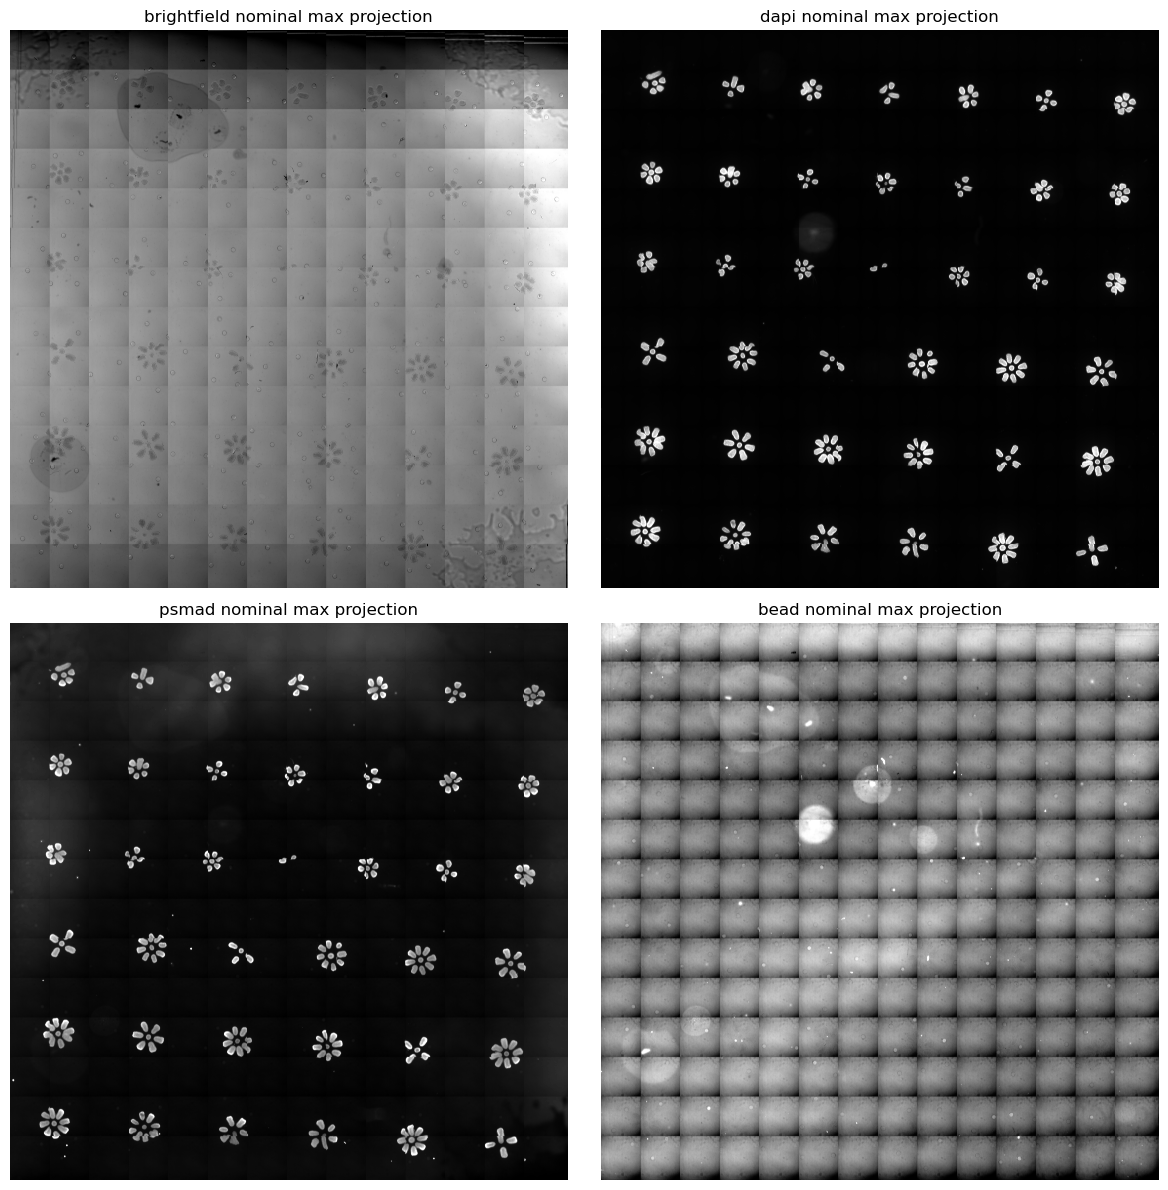

In [ ]:
RAW_DATA_DIR = ROOT / 'data/2024-08-21_pSMAD'
RAW_CZI = {
    'brightfield': RAW_DATA_DIR / 'well3-bright.czi',
    'dapi': RAW_DATA_DIR / 'well3-DAPI.czi',
    'bead': RAW_DATA_DIR / 'well3-555.czi',
    'psmad': RAW_DATA_DIR / 'well3-pSMAD.czi',
}
for path in RAW_CZI.values():
    if not path.exists():
        raise RuntimeError(f'Missing raw CZI needed for nominal-mosaic workflow: {path}')

tile_info = {}
tile_maps = {}
nominal_max = {}
base_key = 'brightfield'
for key, path in RAW_CZI.items():
    info, tile_map = cmh.load_single_channel_tile_map(path, scene_index=0)
    tile_info[key] = info
    tile_maps[key] = tile_map

base_info = tile_info[base_key]
for key, info in tile_info.items():
    if info.y_starts != base_info.y_starts or info.x_starts != base_info.x_starts:
        raise RuntimeError(f'Channel tile lattice mismatch for {key}: y/x starts do not match brightfield.')
    if tuple(info.tile_shape_yx) != tuple(base_info.tile_shape_yx):
        raise RuntimeError(f'Channel tile shape mismatch for {key}: {info.tile_shape_yx} vs {base_info.tile_shape_yx}')

for key, info in tile_info.items():
    nominal_stack = cmh.restitch_single_channel_stack(
        tile_map=tile_maps[key],
        y_starts=info.y_starts,
        x_starts=info.x_starts,
        z_values=info.z_values,
        placements=cmh.build_nominal_placements(info),
    )
    nominal_max[key] = nominal_stack.max(axis=0).astype(np.float32)

print('Loaded raw nominal mosaics for:', ', '.join(sorted(nominal_max)))
print('Shared tile lattice:', len(base_info.y_starts), 'rows x', len(base_info.x_starts), 'cols')
print('Tile shape (px):', base_info.tile_shape_yx)
order = ['brightfield', 'dapi', 'psmad', 'bead']
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for ax, key in zip(axes.ravel(), order):
    ax.imshow(cmh.robust_rescale(nominal_max[key]), cmap='gray')
    ax.set_title(f'{key} nominal max projection')
    ax.axis('off')
plt.tight_layout()
plt.show()


## Array Crop Generation And QC

Generate the 39 array crops directly from the nominal raw-tile mosaics using the corrected chip geometry: top 3 rows x 7 columns and bottom 3 rows x 6 columns.


### Array Crop Configuration


In [ ]:
OUT_BASE_DIR = ROOT / 'results/array_crops_39'
OUT_SCENE_DIR = OUT_BASE_DIR / 'scene_images'
OUT_TABLE_DIR = ROOT / 'results/tables'
OUT_BASE_DIR.mkdir(parents=True, exist_ok=True)
OUT_SCENE_DIR.mkdir(parents=True, exist_ok=True)
OUT_TABLE_DIR.mkdir(parents=True, exist_ok=True)

TOP_ROWS = 3
BOTTOM_ROWS = 3
EXPECTED_ROWS = TOP_ROWS + BOTTOM_ROWS
TOP_COLS = 7
BOTTOM_COLS = 6
EXPECTED_ARRAYS = TOP_ROWS * TOP_COLS + BOTTOM_ROWS * BOTTOM_COLS
DETECTION_DOWNSAMPLE = 8
DETECTION_BLUR_SIGMA_DS = 24.0
DETECTION_MIN_DISTANCE_DS = 120
CROP_FRACTION_OF_GRID_SPACING = 0.82
LOCAL_ALIGN_MARGIN_PX = 160
LOCAL_ALIGN_UPSAMPLE_FACTOR = 20
LOCAL_ALIGN_MAX_SHIFT_FROM_NOMINAL_PX = 72
LOCAL_ALIGN_KEEP_TOP_N = 3
LOCAL_ALIGN_METHOD = 'dapi_bf_global_fill'
LOCAL_ALIGN_EVIDENCE_CHANNELS = ('dapi', 'brightfield')
DEBUG_REVIEW_SCENE_IDS = []
DEBUG_REVIEW_COUNT = 2
SEAM_DEBUG_SCENE_IDS = ['scene00']
LOCAL_REFINE_PERCENTILE = 99.0
LOCAL_REFINE_SMOOTH_SIGMA = 3.0
LOCAL_REFINE_CENTRAL_FRACTION = 0.85
LOCAL_REFINE_MAX_SHIFT_FRACTION = 0.18
WRITE_SCENE_IMAGES = True

CROP_MANIFEST_TSV = OUT_TABLE_DIR / 'dataset2_array_crop_manifest_39.tsv'

print('ROI discovery source: nominal raw-tile mosaics')
print('Expected layout: top 3 rows x 7 cols, bottom 3 rows x 6 cols = 39 arrays')
print('ROI-local alignment source: DAPI-positive seams drive BF shifts; remaining seams use the global orientation step')
bf = nominal_max['brightfield'].astype(np.float32)
dapi = nominal_max['dapi'].astype(np.float32)
psmad = nominal_max['psmad'].astype(np.float32)
bead = nominal_max['bead'].astype(np.float32)


ROI discovery source: nominal raw-tile mosaics
Expected layout: top 3 rows x 7 cols, bottom 3 rows x 6 cols = 39 arrays


### Detect Array Centers


In [ ]:
seed_centers_df, qc = cmh.detect_array_grid_centers_split_blocks(
    dapi_img=dapi,
    top_rows=TOP_ROWS,
    bottom_rows=BOTTOM_ROWS,
    top_cols=TOP_COLS,
    bottom_cols=BOTTOM_COLS,
    downsample=DETECTION_DOWNSAMPLE,
    blur_sigma_ds=DETECTION_BLUR_SIGMA_DS,
    min_distance_ds=DETECTION_MIN_DISTANCE_DS,
)
crop_size_px = cmh.derive_crop_size_px(
    row_spacing_px=qc['row_spacing_px'],
    col_spacing_px=qc['col_spacing_px'],
    crop_fraction=CROP_FRACTION_OF_GRID_SPACING,
)
print('Detected arrays:', len(seed_centers_df))
print('Expected arrays:', EXPECTED_ARRAYS)
print('Derived crop size (px):', crop_size_px)
print('Detection mode:', qc.get('detection_mode', 'unknown'))
if qc.get('inferred_missing_cols'):
    print('Rows with inferred edge positions:', qc['inferred_missing_cols'])
display(seed_centers_df[[
    'grid_block', 'grid_row', 'grid_col', 'center_y_px', 'center_x_px', 'inferred_center'
]].head(10))


Detected arrays: 39
Expected arrays: 39
Derived crop size (px): 1492
Detection mode: split_row_blocks
Local DAPI recentering median shift (px): 153.13181843653507
Local DAPI recentering max shift (px): 288.1156895576466


  grid_block  grid_row  grid_col  seed_center_y_px  seed_center_x_px  \
0        top         0         0            1464.0       1267.734885   
1        top         0         1            1464.0       3076.012039   
2        top         0         2            1464.0       4908.292873   
3        top         0         3            1464.0       6724.571253   
4        top         0         4            1464.0       8540.849634   
5        top         0         5            1464.0      10365.129241   
6        top         0         6            1464.0      12197.410075   
7        top         1         0            3520.0       1176.000000   
8        top         1         1            3520.0       2984.000000   
9        top         1         2            3520.0       4816.000000   

   center_y_px   center_x_px  local_shift_y_px  local_shift_x_px  \
0  1295.749038   1313.709284       -168.250962         45.974399   
1  1316.646494   3133.238771       -147.353506         57.226732   
2  

### Save Stage Outputs


In [ ]:
rows = []
image_h, image_w = dapi.shape
half = int(crop_size_px // 2)

for idx, row in seed_centers_df.reset_index(drop=True).iterrows():
    scene_id = f'scene{idx:02d}'
    bundle = cmh.extract_locally_aligned_roi_bundle(
        channel_infos=tile_info,
        channel_tile_maps=tile_maps,
        seed_center_y_px=float(row.center_y_px),
        seed_center_x_px=float(row.center_x_px),
        crop_size_px=int(crop_size_px),
        evidence_channels=LOCAL_ALIGN_EVIDENCE_CHANNELS,
        align_margin_px=int(LOCAL_ALIGN_MARGIN_PX),
        align_upsample_factor=int(LOCAL_ALIGN_UPSAMPLE_FACTOR),
        align_max_shift_from_nominal_px=int(LOCAL_ALIGN_MAX_SHIFT_FROM_NOMINAL_PX),
        align_keep_top_n=int(LOCAL_ALIGN_KEEP_TOP_N),
        align_method=str(LOCAL_ALIGN_METHOD),
        refine_reference_channel='dapi',
        refine_percentile=float(LOCAL_REFINE_PERCENTILE),
        refine_smooth_sigma=float(LOCAL_REFINE_SMOOTH_SIGMA),
        refine_central_fraction=float(LOCAL_REFINE_CENTRAL_FRACTION),
        refine_max_shift_fraction=float(LOCAL_REFINE_MAX_SHIFT_FRACTION),
    )
    bf_crop = bundle['max_crops']['brightfield']
    dapi_crop = bundle['max_crops']['dapi']
    psmad_crop = bundle['max_crops']['psmad']
    bead_crop = bundle['max_crops']['bead']

    bf_path = OUT_SCENE_DIR / f'{scene_id}_bf.tif'
    dapi_path = OUT_SCENE_DIR / f'{scene_id}_dapi.tif'
    psmad_path = OUT_SCENE_DIR / f'{scene_id}_psmad.tif'
    bead_path = OUT_SCENE_DIR / f'{scene_id}_bead.tif'

    if WRITE_SCENE_IMAGES:
        cmh.write_tiff(bf_path, bf_crop.astype(np.float32))
        cmh.write_tiff(dapi_path, dapi_crop.astype(np.float32))
        cmh.write_tiff(psmad_path, psmad_crop.astype(np.float32))
        cmh.write_tiff(bead_path, bead_crop.astype(np.float32))

    cy = float(bundle['summary']['center_y_px'])
    cx = float(bundle['summary']['center_x_px'])
    y0 = max(0, int(round(cy)) - half)
    x0 = max(0, int(round(cx)) - half)
    y1 = min(int(image_h), y0 + int(crop_size_px))
    x1 = min(int(image_w), x0 + int(crop_size_px))
    y0 = max(0, y1 - int(crop_size_px))
    x0 = max(0, x1 - int(crop_size_px))

    placement_df = bundle['placement_df']
    placement_abs = np.hypot(
        placement_df['delta_from_nominal_y_px'].to_numpy(dtype=np.float64),
        placement_df['delta_from_nominal_x_px'].to_numpy(dtype=np.float64),
    )

    rows.append({
        'scene_index': int(idx),
        'scene_id': scene_id,
        'grid_block': str(row.grid_block),
        'grid_row': int(row.grid_row),
        'grid_col': int(row.grid_col),
        'seed_center_y_px': float(bundle['summary']['seed_center_y_px']),
        'seed_center_x_px': float(bundle['summary']['seed_center_x_px']),
        'center_y_px': float(cy),
        'center_x_px': float(cx),
        'local_shift_y_px': float(bundle['summary']['local_shift_y_px']),
        'local_shift_x_px': float(bundle['summary']['local_shift_x_px']),
        'local_refined': bool(bundle['summary']['local_refined']),
        'local_refine_attempted': bool(bundle['summary']['local_refine_attempted']),
        'local_weight_sum': float(bundle['summary']['local_weight_sum']),
        'local_threshold': float(bundle['summary']['local_threshold']),
        'inferred_center': bool(row.get('inferred_center', False)),
        'center_out_of_bounds': bool((cy < 0) or (cx < 0) or (cy >= image_h) or (cx >= image_w)),
        'touches_left': bool(x0 == 0),
        'touches_right': bool(x1 == image_w),
        'touches_top': bool(y0 == 0),
        'touches_bottom': bool(y1 == image_h),
        'crop_size_px': int(crop_size_px),
        'crop_y0_px': int(y0),
        'crop_x0_px': int(x0),
        'crop_y1_px': int(y1),
        'crop_x1_px': int(x1),
        'roi_tile_row_count': int(bundle['summary']['roi_tile_row_count']),
        'roi_tile_col_count': int(bundle['summary']['roi_tile_col_count']),
        'roi_tile_count': int(bundle['summary']['roi_tile_count']),
        'roi_local_align_applied': bool(bundle['summary']['roi_local_align_applied']),
        'roi_local_align_max_abs_tile_shift_px': float(bundle['summary']['roi_local_align_max_abs_tile_shift_px']),
        'roi_local_align_median_abs_tile_shift_px': float(bundle['summary']['roi_local_align_median_abs_tile_shift_px']),
        'roi_local_align_edge_count': int(bundle['summary']['roi_local_align_edge_count']),
        'roi_local_align_candidate_count': int(bundle['summary']['roi_local_align_candidate_count']),
        'bf_image_path': cmh.rel_to_root(bf_path, ROOT),
        'dapi_image_path': cmh.rel_to_root(dapi_path, ROOT),
        'psmad_image_path': cmh.rel_to_root(psmad_path, ROOT),
        'bead_image_path': cmh.rel_to_root(bead_path, ROOT),
    })

crop_df = pd.DataFrame(rows).sort_values(['grid_row', 'grid_col']).reset_index(drop=True)
if len(crop_df) != EXPECTED_ARRAYS:
    raise RuntimeError(f'Expected {EXPECTED_ARRAYS} crops, found {len(crop_df)}')
crop_df.to_csv(CROP_MANIFEST_TSV, sep='	', index=False)
print('Wrote crop manifest:', CROP_MANIFEST_TSV)
print('ROI-local alignment median max tile shift (px):', float(np.median(crop_df['roi_local_align_max_abs_tile_shift_px'])))
print('ROI-local alignment max tile shift (px):', float(np.max(crop_df['roi_local_align_max_abs_tile_shift_px'])))
print('Final DAPI recentering median shift (px):', float(np.median(np.hypot(crop_df['local_shift_y_px'], crop_df['local_shift_x_px']))))
display(crop_df.head(12))

flagged_df = crop_df.loc[
    crop_df['inferred_center']
    | crop_df['center_out_of_bounds']
    | crop_df['touches_left']
    | crop_df['touches_right']
    | crop_df['touches_top']
    | crop_df['touches_bottom']
].copy()
print('Flagged crops for manual review:', len(flagged_df))
display(flagged_df[[
    'scene_id', 'grid_block', 'grid_row', 'grid_col', 'inferred_center', 'center_out_of_bounds',
    'touches_left', 'touches_right', 'touches_top', 'touches_bottom',
    'seed_center_y_px', 'seed_center_x_px', 'center_y_px', 'center_x_px',
    'local_shift_y_px', 'local_shift_x_px', 'local_refined',
    'roi_tile_row_count', 'roi_tile_col_count', 'roi_local_align_max_abs_tile_shift_px'
]])


Wrote crop manifest: <analysis-root>/pSMAD_2024-08-21/results/tables/dataset2_array_crop_manifest_39.tsv


    scene_index scene_id grid_block  grid_row  grid_col  seed_center_y_px  \
0             0  scene00        top         0         0            1464.0   
1             1  scene01        top         0         1            1464.0   
2             2  scene02        top         0         2            1464.0   
3             3  scene03        top         0         3            1464.0   
4             4  scene04        top         0         4            1464.0   
5             5  scene05        top         0         5            1464.0   
6             6  scene06        top         0         6            1464.0   
7             7  scene07        top         1         0            3520.0   
8             8  scene08        top         1         1            3520.0   
9             9  scene09        top         1         2            3520.0   
10           10  scene10        top         1         3            3520.0   
11           11  scene11        top         1         4            3520.0   

Flagged crops for manual review: 0


Empty DataFrame
Columns: [scene_id, grid_block, grid_row, grid_col, inferred_center, center_out_of_bounds, touches_left, touches_right, touches_top, touches_bottom, seed_center_y_px, seed_center_x_px, center_y_px, center_x_px, local_shift_y_px, local_shift_x_px, local_refined]
Index: []

### Array Center Overlay


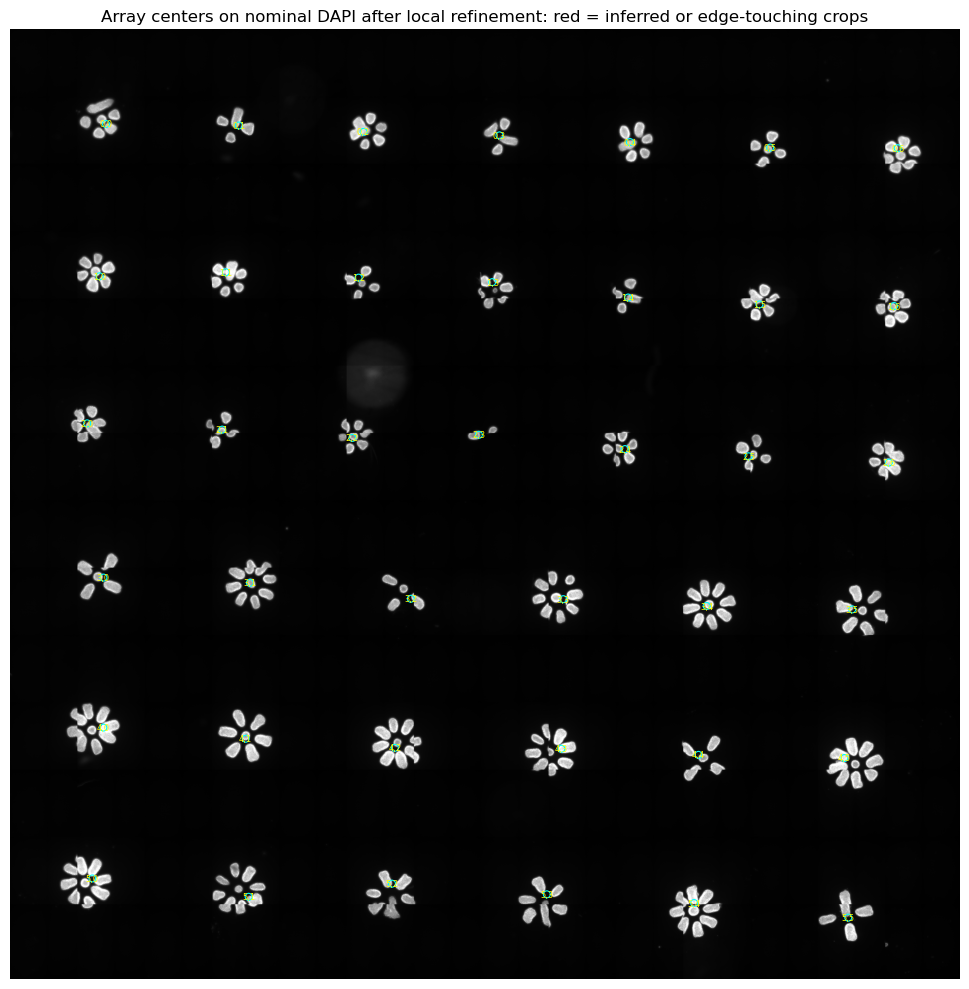

In [ ]:
import matplotlib.patheffects as pe

flagged_df = crop_df.loc[
    crop_df['inferred_center']
    | crop_df['center_out_of_bounds']
    | crop_df['touches_left']
    | crop_df['touches_right']
    | crop_df['touches_top']
    | crop_df['touches_bottom']
].copy()

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(cmh.robust_rescale(dapi), cmap='gray')
normal_df = crop_df.loc[~crop_df['scene_id'].isin(flagged_df['scene_id'])]
flagged_ids = set(flagged_df['scene_id'])
label_offset_px = float(crop_size_px) * 0.34
ax.scatter(normal_df['center_x_px'], normal_df['center_y_px'], s=140, facecolors='none', edgecolors='cyan', linewidths=2.4)
ax.scatter(flagged_df['center_x_px'], flagged_df['center_y_px'], s=220, facecolors='none', edgecolors='red', linewidths=3.2)
for _, r in crop_df.iterrows():
    label = f"{int(r.grid_row)},{int(r.grid_col)}"
    color = 'red' if r['scene_id'] in flagged_ids else 'white'
    label_y = max(float(r.center_y_px) - label_offset_px, 30.0)
    txt = ax.text(
        r.center_x_px,
        label_y,
        label,
        color=color,
        fontsize=18,
        fontweight='bold',
        ha='center',
        va='bottom',
    )
    txt.set_path_effects([pe.withStroke(linewidth=3.5, foreground='black')])
ax.set_title('Array centers on nominal DAPI; final centers come from ROI-local BF alignment plus local DAPI refinement', fontsize=15)
ax.axis('off')
plt.tight_layout()
plt.show()


### Flagged Crop Review


In [ ]:
flagged_df = crop_df.loc[
    crop_df['inferred_center']
    | crop_df['center_out_of_bounds']
    | crop_df['touches_left']
    | crop_df['touches_right']
    | crop_df['touches_top']
    | crop_df['touches_bottom']
].copy().reset_index(drop=True)

if flagged_df.empty:
    print('No inferred or edge-touching crops required manual review.')
else:
    n = len(flagged_df)
    ncols = min(4, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, r) in zip(axes, flagged_df.iterrows()):
        crop = tifffile.imread(ROOT / r['dapi_image_path']).astype(np.float32)
        ax.imshow(cmh.robust_rescale(crop), cmap='gray')
        notes = []
        if bool(r['inferred_center']):
            notes.append('inferred')
        if bool(r['center_out_of_bounds']):
            notes.append('center OOB')
        if bool(r['touches_left']):
            notes.append('left edge')
        if bool(r['touches_right']):
            notes.append('right edge')
        if bool(r['touches_top']):
            notes.append('top edge')
        if bool(r['touches_bottom']):
            notes.append('bottom edge')
        ax.set_title(f"{r['scene_id']} ({int(r['grid_row'])},{int(r['grid_col'])})\n" + ', '.join(notes), fontsize=10)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('red')
            spine.set_linewidth(2.0)
        ax.set_xticks([])
        ax.set_yticks([])
    for ax in axes[n:]:
        ax.axis('off')
    fig.suptitle('Flagged crop review on DAPI crops', fontsize=14)
    plt.tight_layout()
    plt.show()

No inferred or edge-touching crops required manual review.


### Scene00 Seam Debug Review


In [ ]:
import matplotlib.patches as patches

print(
    f"Brightfield raw tile geometry: {tile_info['brightfield'].tile_shape_yx[0]} x {tile_info['brightfield'].tile_shape_yx[1]} px tiles; "
    f"nominal step {int(tile_info['brightfield'].nominal_dy_px)} x {int(tile_info['brightfield'].nominal_dx_px)} px; "
    f"raw overlap {int(tile_info['brightfield'].tile_shape_yx[0] - tile_info['brightfield'].nominal_dy_px)} x {int(tile_info['brightfield'].tile_shape_yx[1] - tile_info['brightfield'].nominal_dx_px)} px."
)
print('Interpretation: the raw dataset has real tile overlap; scene00 seam failures should be recoverable if the local alignment is correct.')


def _edge_shift_from_nominal(edge_row):
    if str(edge_row['edge_type']) == 'horizontal':
        dy_shift = float(edge_row['delta_y_px'])
        dx_shift = float(edge_row['delta_x_px']) - float(edge_row['nominal_dx_px'])
    else:
        dy_shift = float(edge_row['delta_y_px']) - float(edge_row['nominal_dy_px'])
        dx_shift = float(edge_row['delta_x_px'])
    return float(np.hypot(dy_shift, dx_shift))


def _draw_tile_boxes_nominal(ax, placement_df, crop_bounds, tile_shape_yx, color='deepskyblue'):
    th, tw = int(tile_shape_yx[0]), int(tile_shape_yx[1])
    for _, prow in placement_df.iterrows():
        x = float(prow['raw_x_start_px']) - float(crop_bounds['x0'])
        y = float(prow['raw_y_start_px']) - float(crop_bounds['y0'])
        rect = patches.Rectangle((x, y), tw, th, fill=False, edgecolor=color, linewidth=2.0)
        ax.add_patch(rect)
        ax.text(x + 18, y + 30, f"{int(prow['local_tile_row'])},{int(prow['local_tile_col'])}", color=color, fontsize=10, fontweight='bold')


def _draw_tile_boxes_registered(ax, placement_df, crop_bounds_local, tile_shape_yx, color='deepskyblue'):
    th, tw = int(tile_shape_yx[0]), int(tile_shape_yx[1])
    for _, prow in placement_df.iterrows():
        x = float(prow['registered_x_px']) - float(crop_bounds_local['x0'])
        y = float(prow['registered_y_px']) - float(crop_bounds_local['y0'])
        rect = patches.Rectangle((x, y), tw, th, fill=False, edgecolor=color, linewidth=2.0)
        ax.add_patch(rect)
        ax.text(x + 18, y + 30, f"{int(prow['local_tile_row'])},{int(prow['local_tile_col'])}", color=color, fontsize=10, fontweight='bold')


def _zoom_bounds_from_edge(edge_row, placement_df, tile_shape_yx, crop_bounds, crop_bounds_local, crop_size_px, pad_px=80):
    th, tw = int(tile_shape_yx[0]), int(tile_shape_yx[1])
    sel = placement_df[
        ((placement_df['local_tile_row'] == int(edge_row['local_r0'])) & (placement_df['local_tile_col'] == int(edge_row['local_c0']))) |
        ((placement_df['local_tile_row'] == int(edge_row['local_r1'])) & (placement_df['local_tile_col'] == int(edge_row['local_c1'])))
    ].copy()
    if len(sel) != 2:
        return None, None

    xs0 = sel['raw_x_start_px'].to_numpy(dtype=float) - float(crop_bounds['x0'])
    ys0 = sel['raw_y_start_px'].to_numpy(dtype=float) - float(crop_bounds['y0'])
    nominal_bounds = (
        max(0.0, xs0.min() - pad_px),
        min(float(crop_size_px), (xs0 + tw).max() + pad_px),
        max(0.0, ys0.min() - pad_px),
        min(float(crop_size_px), (ys0 + th).max() + pad_px),
    )

    xs1 = sel['registered_x_px'].to_numpy(dtype=float) - float(crop_bounds_local['x0'])
    ys1 = sel['registered_y_px'].to_numpy(dtype=float) - float(crop_bounds_local['y0'])
    aligned_bounds = (
        max(0.0, xs1.min() - pad_px),
        min(float(crop_size_px), (xs1 + tw).max() + pad_px),
        max(0.0, ys1.min() - pad_px),
        min(float(crop_size_px), (ys1 + th).max() + pad_px),
    )
    return nominal_bounds, aligned_bounds


scene_lookup = crop_df.set_index('scene_id')
seam_debug_scene_ids = [sid for sid in SEAM_DEBUG_SCENE_IDS if sid in scene_lookup.index]
print('Seam debug scenes:', seam_debug_scene_ids)
for scene_id in seam_debug_scene_ids:
    row = scene_lookup.loc[scene_id]
    bundle = cmh.extract_locally_aligned_roi_bundle(
        channel_infos=tile_info,
        channel_tile_maps=tile_maps,
        seed_center_y_px=float(row['seed_center_y_px']),
        seed_center_x_px=float(row['seed_center_x_px']),
        crop_size_px=int(crop_size_px),
        evidence_channels=LOCAL_ALIGN_EVIDENCE_CHANNELS,
        align_margin_px=int(LOCAL_ALIGN_MARGIN_PX),
        align_upsample_factor=int(LOCAL_ALIGN_UPSAMPLE_FACTOR),
        align_max_shift_from_nominal_px=int(LOCAL_ALIGN_MAX_SHIFT_FROM_NOMINAL_PX),
        align_keep_top_n=int(LOCAL_ALIGN_KEEP_TOP_N),
        align_method=str(LOCAL_ALIGN_METHOD),
        refine_reference_channel='dapi',
        refine_percentile=float(LOCAL_REFINE_PERCENTILE),
        refine_smooth_sigma=float(LOCAL_REFINE_SMOOTH_SIGMA),
        refine_central_fraction=float(LOCAL_REFINE_CENTRAL_FRACTION),
        refine_max_shift_fraction=float(LOCAL_REFINE_MAX_SHIFT_FRACTION),
    )
    nominal_bf, nominal_bounds = cmh.crop_square_with_bounds(bf, float(row['seed_center_y_px']), float(row['seed_center_x_px']), int(crop_size_px))
    nominal_dapi, _ = cmh.crop_square_with_bounds(dapi, float(row['seed_center_y_px']), float(row['seed_center_x_px']), int(crop_size_px))
    aligned_bf = bundle['seed_max_crops']['brightfield']
    aligned_dapi = bundle['seed_max_crops']['dapi']

    edge_df_debug = bundle['edge_df'].copy()
    edge_df_debug['shift_from_nominal_px'] = edge_df_debug.apply(_edge_shift_from_nominal, axis=1)
    worst_edge = edge_df_debug.sort_values('shift_from_nominal_px', ascending=False).iloc[0]
    nominal_zoom, aligned_zoom = _zoom_bounds_from_edge(
        worst_edge,
        bundle['placement_df'],
        tile_info['brightfield'].tile_shape_yx,
        nominal_bounds,
        bundle['seed_crop_bounds_local'],
        int(crop_size_px),
    )

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    titles = [
        'Nominal seed crop',
        'ROI-local BF alignment',
        'Nominal zoom on worst seam',
        'Aligned zoom on worst seam',
    ]
    row_specs = [
        ('BF', nominal_bf, aligned_bf),
        ('DAPI', nominal_dapi, aligned_dapi),
    ]
    for ridx, (label, nominal_img, aligned_img) in enumerate(row_specs):
        ax0, ax1, ax2, ax3 = axes[ridx]
        ax0.imshow(cmh.robust_rescale(nominal_img), cmap='gray')
        _draw_tile_boxes_nominal(ax0, bundle['placement_df'], nominal_bounds, tile_info['brightfield'].tile_shape_yx)
        rect0 = patches.Rectangle((nominal_zoom[0], nominal_zoom[2]), nominal_zoom[1]-nominal_zoom[0], nominal_zoom[3]-nominal_zoom[2], fill=False, edgecolor='red', linewidth=2.5)
        ax0.add_patch(rect0)

        ax1.imshow(cmh.robust_rescale(aligned_img), cmap='gray')
        _draw_tile_boxes_registered(ax1, bundle['placement_df'], bundle['seed_crop_bounds_local'], tile_info['brightfield'].tile_shape_yx)
        rect1 = patches.Rectangle((aligned_zoom[0], aligned_zoom[2]), aligned_zoom[1]-aligned_zoom[0], aligned_zoom[3]-aligned_zoom[2], fill=False, edgecolor='red', linewidth=2.5)
        ax1.add_patch(rect1)

        ax2.imshow(cmh.robust_rescale(nominal_img), cmap='gray')
        _draw_tile_boxes_nominal(ax2, bundle['placement_df'], nominal_bounds, tile_info['brightfield'].tile_shape_yx)
        ax2.set_xlim(nominal_zoom[0], nominal_zoom[1])
        ax2.set_ylim(nominal_zoom[3], nominal_zoom[2])

        ax3.imshow(cmh.robust_rescale(aligned_img), cmap='gray')
        _draw_tile_boxes_registered(ax3, bundle['placement_df'], bundle['seed_crop_bounds_local'], tile_info['brightfield'].tile_shape_yx)
        ax3.set_xlim(aligned_zoom[0], aligned_zoom[1])
        ax3.set_ylim(aligned_zoom[3], aligned_zoom[2])

        for cidx, ax in enumerate([ax0, ax1, ax2, ax3]):
            if ridx == 0:
                ax.set_title(titles[cidx], fontsize=11)
            if cidx == 0:
                ax.set_ylabel(label, fontsize=11)
            ax.set_xticks([])
            ax.set_yticks([])

    fig.suptitle(
        f"{scene_id} | r{int(row['grid_row'])} c{int(row['grid_col'])} | worst seam {str(worst_edge['edge_type'])} ({int(worst_edge['local_r0'])},{int(worst_edge['local_c0'])}) -> ({int(worst_edge['local_r1'])},{int(worst_edge['local_c1'])}) | shift from nominal {float(worst_edge['shift_from_nominal_px']):.1f}px",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

    display(edge_df_debug[[
        'edge_type', 'local_r0', 'local_c0', 'local_r1', 'local_c1',
        'best_evidence_id', 'n_candidates', 'n_used', 'quality_median', 'shift_from_nominal_px'
    ]].sort_values('shift_from_nominal_px', ascending=False).reset_index(drop=True))
    display(bundle['placement_df'][[
        'local_tile_row', 'local_tile_col', 'global_tile_row', 'global_tile_col',
        'delta_from_nominal_y_px', 'delta_from_nominal_x_px'
    ]])


### Representative Alignment Debug Review


In [ ]:

scene_lookup = crop_df.set_index('scene_id')
if DEBUG_REVIEW_SCENE_IDS:
    debug_scene_ids = [sid for sid in DEBUG_REVIEW_SCENE_IDS if sid in scene_lookup.index]
    if not debug_scene_ids:
        print('No requested DEBUG_REVIEW_SCENE_IDS were found in crop_df.')
else:
    ranked = crop_df.sort_values(
        ['roi_local_align_max_abs_tile_shift_px', 'roi_local_align_candidate_count', 'scene_index'],
        ascending=[False, False, True],
    )
    debug_scene_ids = ranked['scene_id'].head(int(DEBUG_REVIEW_COUNT)).tolist()

print('Representative debug scenes:', debug_scene_ids)
for scene_id in debug_scene_ids:
    row = scene_lookup.loc[scene_id]
    bundle = cmh.extract_locally_aligned_roi_bundle(
        channel_infos=tile_info,
        channel_tile_maps=tile_maps,
        seed_center_y_px=float(row['seed_center_y_px']),
        seed_center_x_px=float(row['seed_center_x_px']),
        crop_size_px=int(crop_size_px),
        evidence_channels=LOCAL_ALIGN_EVIDENCE_CHANNELS,
        align_margin_px=int(LOCAL_ALIGN_MARGIN_PX),
        align_upsample_factor=int(LOCAL_ALIGN_UPSAMPLE_FACTOR),
        align_max_shift_from_nominal_px=int(LOCAL_ALIGN_MAX_SHIFT_FROM_NOMINAL_PX),
        align_keep_top_n=int(LOCAL_ALIGN_KEEP_TOP_N),
        align_method=str(LOCAL_ALIGN_METHOD),
        refine_reference_channel='dapi',
        refine_percentile=float(LOCAL_REFINE_PERCENTILE),
        refine_smooth_sigma=float(LOCAL_REFINE_SMOOTH_SIGMA),
        refine_central_fraction=float(LOCAL_REFINE_CENTRAL_FRACTION),
        refine_max_shift_fraction=float(LOCAL_REFINE_MAX_SHIFT_FRACTION),
    )
    nominal_bf, _ = cmh.crop_square_with_bounds(bf, float(row['seed_center_y_px']), float(row['seed_center_x_px']), int(crop_size_px))
    nominal_dapi, _ = cmh.crop_square_with_bounds(dapi, float(row['seed_center_y_px']), float(row['seed_center_x_px']), int(crop_size_px))

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    stage_titles = ['Nominal seed crop', 'Locally aligned before recenter', 'Final crop']
    channel_specs = [
        ('brightfield', 'BF', nominal_bf, bundle['seed_max_crops']['brightfield'], bundle['max_crops']['brightfield']),
        ('dapi', 'DAPI', nominal_dapi, bundle['seed_max_crops']['dapi'], bundle['max_crops']['dapi']),
    ]
    for row_idx, (_, channel_label, nominal_img, aligned_seed_img, final_img) in enumerate(channel_specs):
        for col_idx, img in enumerate([nominal_img, aligned_seed_img, final_img]):
            ax = axes[row_idx, col_idx]
            ax.imshow(cmh.robust_rescale(img), cmap='gray')
            if row_idx == 0:
                ax.set_title(stage_titles[col_idx], fontsize=11)
            if col_idx == 0:
                ax.set_ylabel(channel_label, fontsize=11)
            ax.set_xticks([])
            ax.set_yticks([])
    fig.suptitle(
        f"{scene_id} | r{int(row['grid_row'])} c{int(row['grid_col'])} | local tile shift max {float(row['roi_local_align_max_abs_tile_shift_px']):.1f}px | recenter ({float(row['local_shift_y_px']):.1f}, {float(row['local_shift_x_px']):.1f})",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

    display(bundle['placement_df'][[
        'local_tile_row', 'local_tile_col', 'global_tile_row', 'global_tile_col',
        'delta_from_nominal_y_px', 'delta_from_nominal_x_px'
    ]])
    display(bundle['edge_df'][[
        'edge_type', 'local_r0', 'local_c0', 'local_r1', 'local_c1',
        'best_evidence_id', 'n_candidates', 'n_used', 'quality_median'
    ]].head(12))


### Full Grid Review


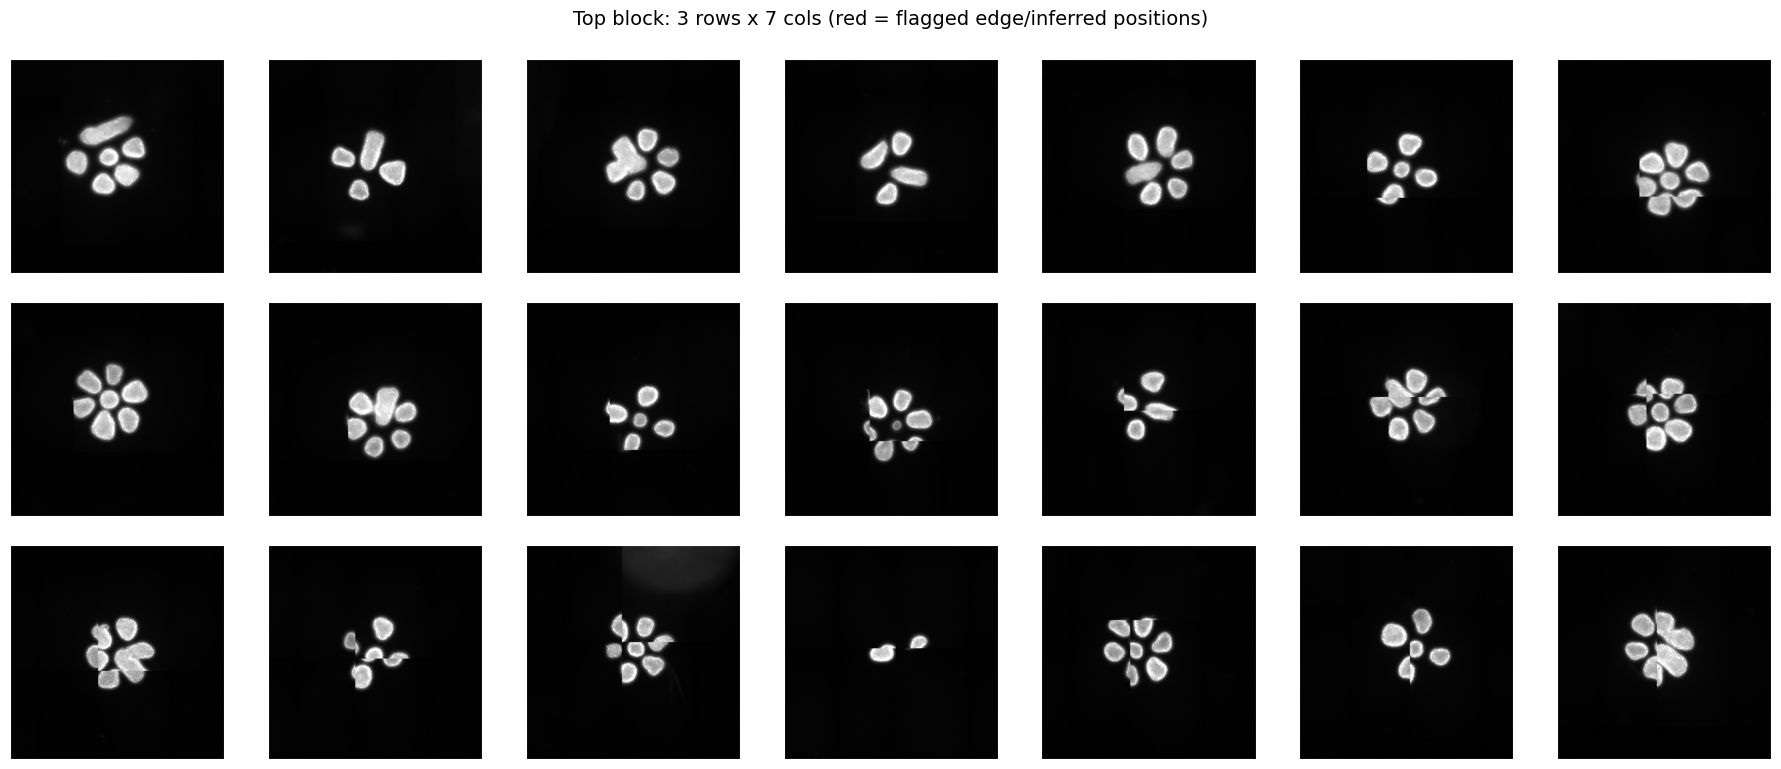

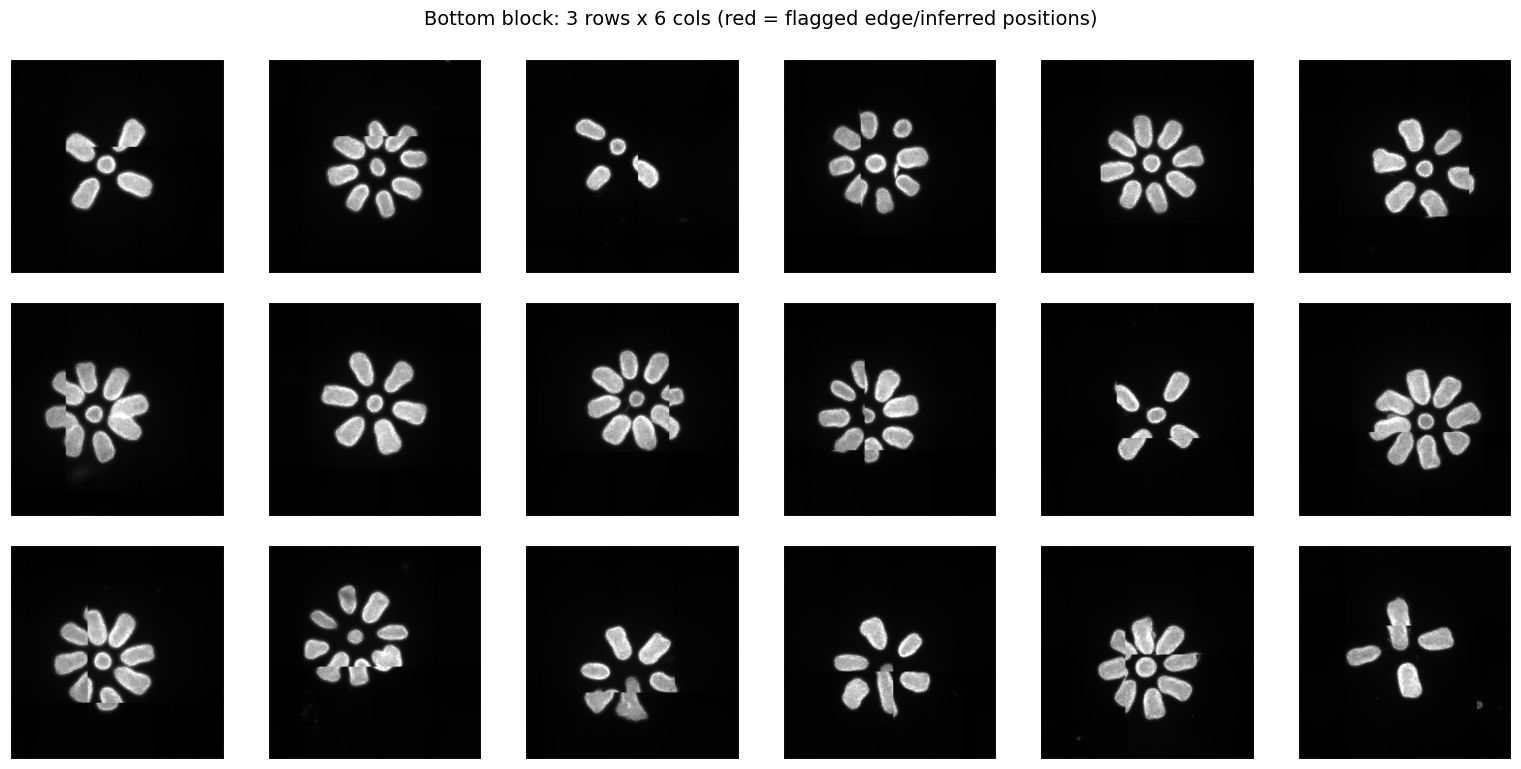

In [ ]:

def plot_block_pair_grid(block_df: pd.DataFrame, n_block_rows: int, n_block_cols: int, title: str):
    fig, axes = plt.subplots(n_block_rows * 2, n_block_cols, figsize=(2.8 * n_block_cols, 3.0 * n_block_rows * 2))
    axes = np.asarray(axes)
    if axes.ndim == 1:
        axes = axes.reshape(n_block_rows * 2, n_block_cols)

    total_slots = n_block_rows * n_block_cols
    rows = list(block_df.reset_index(drop=True).iterrows())
    for idx in range(total_slots):
        block_row = idx // n_block_cols
        block_col = idx % n_block_cols
        bf_ax = axes[block_row * 2, block_col]
        dapi_ax = axes[block_row * 2 + 1, block_col]
        if idx >= len(rows):
            bf_ax.axis('off')
            dapi_ax.axis('off')
            continue
        _, r = rows[idx]
        bf_crop = tifffile.imread(ROOT / r['bf_image_path']).astype(np.float32)
        dapi_crop = tifffile.imread(ROOT / r['dapi_image_path']).astype(np.float32)
        flag = bool(r['inferred_center'] or r['center_out_of_bounds'] or r['touches_left'] or r['touches_right'] or r['touches_top'] or r['touches_bottom'])
        border_color = 'red' if flag else 'white'

        bf_ax.imshow(cmh.robust_rescale(bf_crop), cmap='gray')
        dapi_ax.imshow(cmh.robust_rescale(dapi_crop), cmap='gray')
        bf_ax.set_title(f"{r['scene_id']}\nr{int(r['grid_row'])} c{int(r['grid_col'])}", fontsize=9, color=border_color)
        bf_ax.text(0.03, 0.97, 'BF', transform=bf_ax.transAxes, ha='left', va='top', color='white', fontsize=8, fontweight='bold')
        dapi_ax.text(0.03, 0.97, 'DAPI', transform=dapi_ax.transAxes, ha='left', va='top', color='white', fontsize=8, fontweight='bold')
        for ax in (bf_ax, dapi_ax):
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor(border_color)
                spine.set_linewidth(1.6 if flag else 0.8)
            ax.set_xticks([])
            ax.set_yticks([])

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


top_df = crop_df.loc[crop_df['grid_block'] == 'top'].sort_values(['grid_row', 'grid_col']).reset_index(drop=True)
bottom_df = crop_df.loc[crop_df['grid_block'] == 'bottom'].sort_values(['grid_row', 'grid_col']).reset_index(drop=True)
plot_block_pair_grid(top_df, TOP_ROWS, TOP_COLS, 'Top block: paired BF + DAPI after ROI-local BF tile correction')
plot_block_pair_grid(bottom_df, BOTTOM_ROWS, BOTTOM_COLS, 'Bottom block: paired BF + DAPI after ROI-local BF tile correction')
